In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader

### Get File path and load the csv data

In [21]:
from util.data_path import cassava_price_avg as data_file

In [22]:
wide = pd.read_csv(data_file)
long = wide.melt(id_vars="year", var_name="month", value_name="price").sort_values(
    ["year", "month"]
)

long["date"] = pd.to_datetime(
    (long["year"] - 543).astype(str)
    + "-"
    + long["month"].astype(str).str.zfill(2)
    + "-01"
)
long = long.set_index("date").sort_index()

In [23]:
gregorian_2566 = 2023
gregorian_2567 = 2024

train = long[long.index.year <= gregorian_2566]["price"].to_frame()
future = long[long.index.year == gregorian_2567]["price"].to_frame()

scaler = MinMaxScaler()
train["scaled"] = scaler.fit_transform(train[["price"]])

series = train["scaled"].values.astype(np.float32)

In [24]:
SEQ_LEN = 12
PRED_LEN = 12

### Training the Transformer Model

In [25]:
from util.transformer_cust_class import SeqDataset, TransformerRegressor

In [26]:
series_scaled = train["scaled"].values.astype(np.float32)

ds = SeqDataset(series_scaled, SEQ_LEN, PRED_LEN)
loader = DataLoader(ds, batch_size=len(ds))

model_tf = TransformerRegressor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_tf.parameters(), lr=1e-3)

In [27]:
EPOCHS = 500
for epoch in range(1, EPOCHS + 1):
    for xb, yb in loader:
        optimizer.zero_grad()
        y_pred = model_tf(xb)  # (B, 12)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}/{EPOCHS} — loss = {loss.item():.6f}")


Epoch  50/500 — loss = 0.031811
Epoch 100/500 — loss = 0.023323
Epoch 150/500 — loss = 0.020537
Epoch 200/500 — loss = 0.016294
Epoch 250/500 — loss = 0.013728
Epoch 300/500 — loss = 0.011876
Epoch 350/500 — loss = 0.011163
Epoch 400/500 — loss = 0.009238
Epoch 450/500 — loss = 0.008097
Epoch 500/500 — loss = 0.007459


### Predict the data for the next year

In [28]:
model_tf.eval()
with torch.no_grad():
    window = (
        torch.tensor(series_scaled[-SEQ_LEN:], dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(-1)
    )
    tf_forecast_scaled = model_tf(window).squeeze(0).numpy()
    tf_forecast = scaler.inverse_transform(tf_forecast_scaled.reshape(-1, 1)).flatten()

tf_forecast = pd.Series(
    tf_forecast,
    index=pd.date_range("2024-01-01", periods=12, freq="MS"),
    name="TF_forecast",
)

In [29]:
cmp = pd.concat([future["price"], tf_forecast], axis=1)
print("\n--- Actual vs Forecast (debug view) ---")
print(cmp.round(2))


--- Actual vs Forecast (debug view) ---
            price  TF_forecast
2024-01-01   3.65         3.43
2024-02-01   3.65         3.16
2024-03-01   3.57         3.05
2024-04-01   3.24         2.96
2024-05-01   3.19         2.97
2024-06-01   3.09         2.97
2024-07-01   3.06         3.08
2024-08-01   2.95         3.13
2024-09-01   2.86         3.23
2024-10-01   2.65         3.24
2024-11-01   2.60         3.19
2024-12-01   2.32         3.15


### Compare The Error of a predicted data and the actual data in a table format

In [30]:
error = future["price"] - tf_forecast
abs_error = abs(error)
mae_tf = mean_absolute_error(future["price"], tf_forecast)
print(f"\nTransformer MAE 2567 = {mae_tf:.4f}")


error = pd.DataFrame(
    {
        "actual": future["price"],
        "tf_forecast": tf_forecast,
        "mae_tf": abs_error,
    }
)
print(error.round(3))
print(f"mean absolute error = {mae_tf:.4f}")

print(f"Transformer Accuracy = {100 - (mae_tf / future['price'].mean() * 100):.2f}%")


Transformer MAE 2567 = 0.3697
            actual  tf_forecast  mae_tf
2024-01-01    3.65        3.427   0.223
2024-02-01    3.65        3.158   0.492
2024-03-01    3.57        3.048   0.522
2024-04-01    3.24        2.961   0.279
2024-05-01    3.19        2.974   0.216
2024-06-01    3.09        2.967   0.123
2024-07-01    3.06        3.082   0.022
2024-08-01    2.95        3.127   0.177
2024-09-01    2.86        3.232   0.372
2024-10-01    2.65        3.242   0.592
2024-11-01    2.60        3.188   0.588
2024-12-01    2.32        3.151   0.831
mean absolute error = 0.3697
Transformer Accuracy = 87.95%


### Plot The predicted data compare to an actual data

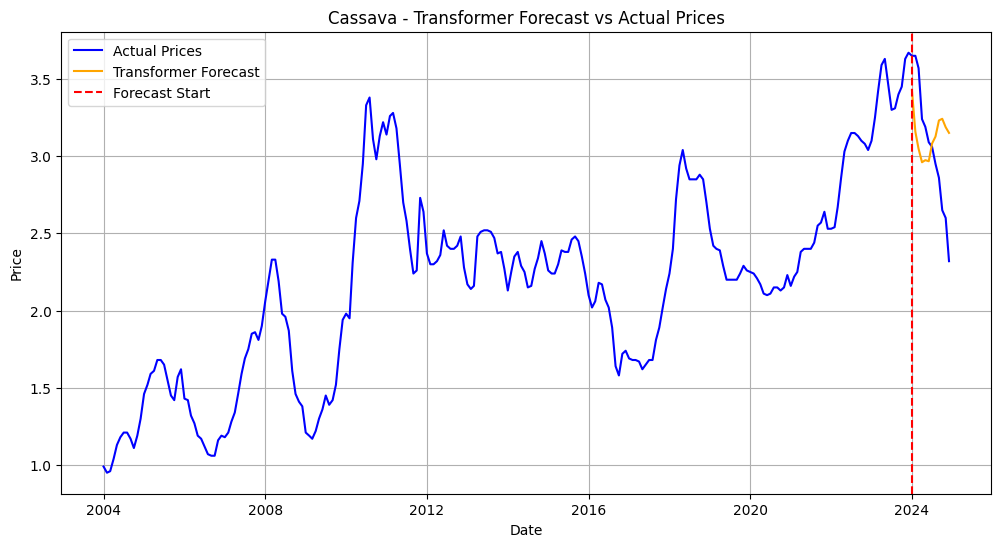

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(long.index, long["price"], label="Actual Prices", color="blue")
plt.plot(tf_forecast.index, tf_forecast, label="Transformer Forecast", color="orange")
plt.axvline(
    x=pd.Timestamp("2024-01-01"), color="red", linestyle="--", label="Forecast Start"
)
plt.title(
    f"{data_file.parent.name.capitalize()} - Transformer Forecast vs Actual Prices"
)
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

<Figure size 1400x800 with 0 Axes>

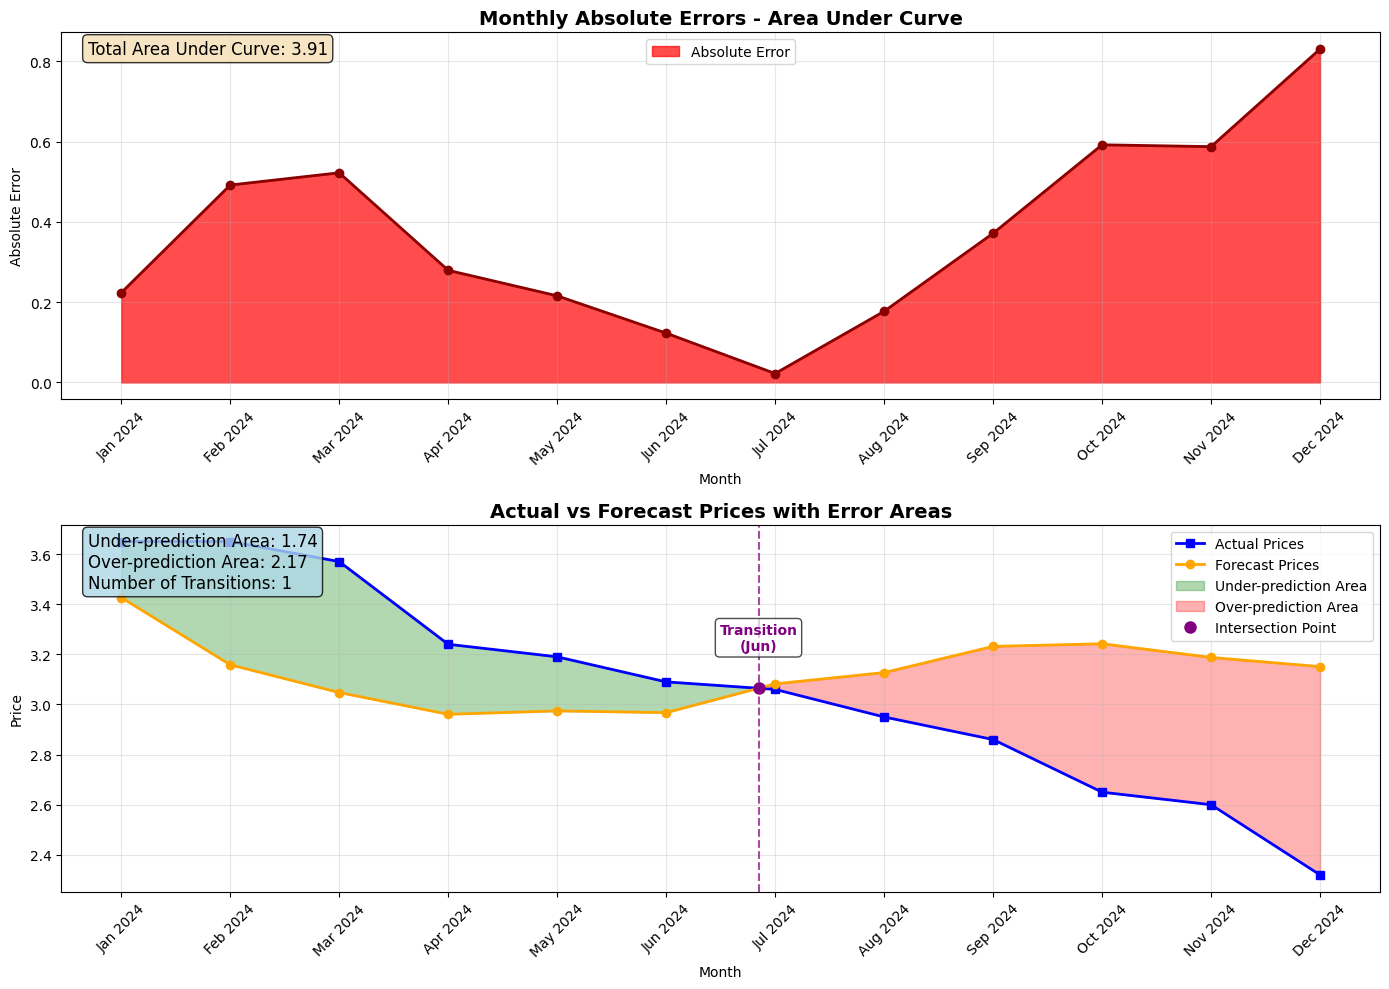

In [32]:
# Create area plot to visualize monthly errors
plt.figure(figsize=(14, 8))

# Calculate error values (in case this cell is run before the error calculation cell)
error = cmp["price"] - cmp["TF_forecast"]
abs_error = abs(error)

# Add the error columns to the cmp DataFrame if they don't exist
if "error" not in cmp.columns:
    cmp["error"] = error
if "abs_error" not in cmp.columns:
    cmp["abs_error"] = abs_error

# Create month labels for better readability
month_labels = [date.strftime("%b %Y") for date in cmp.index]

# Create subplots for different error visualizations
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Area plot of absolute errors
ax1.fill_between(
    range(len(cmp)), cmp["abs_error"], alpha=0.7, color="red", label="Absolute Error"
)
ax1.plot(range(len(cmp)), cmp["abs_error"], color="darkred", linewidth=2, marker="o")
ax1.set_title(
    "Monthly Absolute Errors - Area Under Curve", fontsize=14, fontweight="bold"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Absolute Error")
ax1.set_xticks(range(len(cmp)))
ax1.set_xticklabels(month_labels, rotation=45)
ax1.grid(True, alpha=0.3)
ax1.legend()

# Add area calculation text
total_area = np.trapezoid(cmp["abs_error"])
ax1.text(
    0.02,
    0.98,
    f"Total Area Under Curve: {total_area:.2f}",
    transform=ax1.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Comparison of actual vs forecast with error areas
ax2.plot(
    range(len(cmp)),
    cmp["price"],
    label="Actual Prices",
    color="blue",
    linewidth=2,
    marker="s",
)
ax2.plot(
    range(len(cmp)),
    cmp["TF_forecast"],
    label="Forecast Prices",
    color="orange",
    linewidth=2,
    marker="o",
)

# Find intersection points between actual and forecast
intersect_indices = []
for i in range(1, len(cmp)):
    # Check if actual and forecast cross between i-1 and i
    prev_diff = cmp["price"].iloc[i - 1] - cmp["TF_forecast"].iloc[i - 1]
    curr_diff = cmp["price"].iloc[i] - cmp["TF_forecast"].iloc[i]

    if (prev_diff * curr_diff <= 0) and (
        prev_diff != 0 or curr_diff != 0
    ):  # Sign change or one is zero
        # Linear interpolation to find exact intersection point
        if prev_diff == curr_diff:  # They're equal (both 0)
            t = 0  # At point i-1
        else:
            t = abs(prev_diff) / (abs(prev_diff) + abs(curr_diff))

        intersect_x = (i - 1) + t
        intersect_y = cmp["price"].iloc[i - 1] + t * (
            cmp["price"].iloc[i] - cmp["price"].iloc[i - 1]
        )

        intersect_indices.append((intersect_x, intersect_y))

# Fill areas between actual and forecast to show errors
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["TF_forecast"],
    where=(cmp["price"] >= cmp["TF_forecast"]),
    color="green",
    alpha=0.3,
    label="Under-prediction Area",
    interpolate=True,
)
ax2.fill_between(
    range(len(cmp)),
    cmp["price"],
    cmp["TF_forecast"],
    where=(cmp["price"] < cmp["TF_forecast"]),
    color="red",
    alpha=0.3,
    label="Over-prediction Area",
    interpolate=True,
)

# Mark intersection points with vertical lines and markers
for idx, (x, y) in enumerate(intersect_indices):
    ax2.axvline(x, color="purple", linestyle="--", alpha=0.7, linewidth=1.5)
    ax2.plot(
        x,
        y,
        "o",
        color="purple",
        markersize=8,
        label="Intersection Point" if idx == 0 else "",
    )
    ax2.text(
        x,
        y * 1.05,
        f"Transition\n({month_labels[int(x)][:3]})",
        ha="center",
        color="purple",
        fontweight="bold",
        bbox=dict(facecolor="white", alpha=0.7, boxstyle="round,pad=0.3"),
    )

ax2.set_title(
    "Actual vs Forecast Prices with Error Areas", fontsize=14, fontweight="bold"
)
ax2.set_xlabel("Month")
ax2.set_ylabel("Price")
ax2.set_xticks(range(len(cmp)))
ax2.set_xticklabels(month_labels, rotation=45)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="upper right")

# Calculate and display area statistics
under_pred_area = np.trapezoid(np.maximum(cmp["price"] - cmp["TF_forecast"], 0))
over_pred_area = np.trapezoid(np.maximum(cmp["TF_forecast"] - cmp["price"], 0))

# Count number of transitions
num_transitions = len(intersect_indices)

# Create statistics text
stats_text = (
    f"Under-prediction Area: {under_pred_area:.2f}\n"
    f"Over-prediction Area: {over_pred_area:.2f}\n"
    f"Number of Transitions: {num_transitions}"
)

ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8),
)

plt.tight_layout()
plt.show()